<a href="https://colab.research.google.com/github/majortank/AI-Course-2026/blob/main/Homework_One.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vaal Medical Group ML Challenge: Data Pre-processing & Predictive Modeling

## 1. Initial Setup

In [78]:
# Import core data manipulation libraries
import pandas as pd
import numpy as np
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
# Import machine ,earning and evaluation metrics from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 2. Loading Data

In [79]:
# 1. Load the dataset
df = pd.read_csv('/content/data/sa_healthcare_big_messy.csv')

## Initial Audit

### Get a quick sammary of the DataFrame

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5030 non-null   int64  
 1   sex       5030 non-null   object 
 2   bmi       4778 non-null   float64
 3   children  5030 non-null   int64  
 4   smoker    5030 non-null   object 
 5   region    5030 non-null   object 
 6   charges   5030 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 275.2+ KB


### Get statistics for numeric columns

In [81]:
df.describe()

,age,bmi,children
count,5030.000000,4778.000000,5030.000000
mean,39.500795,30.612060,1.075348
std,15.805171,6.180599,1.181521
min,-12.000000,15.960000,0.000000
25%,26.000000,26.200000,0.000000
50%,39.000000,30.250000,1.000000
75%,51.000000,34.770000,2.000000
max,140.000000,53.130000,5.000000


In [82]:
print(f"Data type of 'charges' before cleaning: {df['charges'].dtype}")
print(f"Number of missing values (NaN) in the 'bmi' column: {df['bmi'].isna().sum()}")

Data type of 'charges' before cleaning: object
Number of missing values (NaN) in the 'bmi' column: 252


## Data Engineering and Cleaning

### Remove Duplicate Rows

In [83]:
# See duplicates before removing them
print(df.duplicated().sum())
df[df.duplicated()]

3284


,age,sex,bmi,children,smoker,region,charges
56,31,male,39.490,1,no,KwaZulu-Natal,"R3,875.73"
74,58,male,25.175,0,no,Eastern Cape,"R11,931.13"
124,51,male,23.210,1,yes,KwaZulu-Natal,"R22,218.11"
155,64,male,26.410,0,no,Eastern Cape,"R14,394.56"
167,18,female,39.820,0,no,KwaZulu-Natal,"R1,633.96"
...,...,...,...,...,...,...,...
5025,140,female,30.210,3,no,Gauteng,"R7,537.16"
5026,19,male,20.615,2,no,Gauteng,"R2,803.70"
5027,32,female,20.520,0,no,Eastern Cape,"R4,544.23"
5028,62,female,39.200,0,no,Western Cape,"R13,470.86"


In [84]:
initial_row_count = len(df)

In [85]:
df = df.drop_duplicates()

In [86]:
duplicates_removed = initial_row_count - len(df)

In [87]:
print(f"1. Total number of duplicates rows  removed: {duplicates_removed}")

1. Total number of duplicates rows  removed: 3284


In [88]:
print(df.duplicated().sum())

0


### Harmonize Strings (Regions, Sex, Smoker)

#### Find variations of "Gauteng" before cleaning to answer Section 6.2.2

In [89]:
gauteng_variations = [region for region in df['region'].dropna().unique() if 'gauteng' in str(region).lower()]
print(f"2. Variations of 'Gauteng' found: {gauteng_variations}")

2. Variations of 'Gauteng' found: ['GAUTENG', 'Gauteng', 'gauteng']


### Clean string columns by stripping whitespace and standardizing case

In [90]:
df['region'] = df['region'].str.strip().str.title()
df['sex'] = df['sex'].str.strip().str.title()
df['smoker'] = df['smoker'].str.strip().str.title()

### Type Casting the Target Variable ('charges')

In [91]:
# Remove 'R' symbol and commas, then convert the remaining to a float
df['charges'] = df['charges'].str.replace('R', '', regex=False).str.replace(',', '', regex=False).astype(float)

### Handle Missing Values

In [92]:
# Impute missing BMI values with the median BMI of the dataset
# why Median
# 1. Using mean might give a value too high or too low if there are extreme BMI values
#. Using median ensures that the imputed value is typical of the dataset, not distorted by outliers.

In [93]:
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)

### Remove Outliers (Biological Impossibilities)

In [95]:
# Filter out rows where age is less than 0 or greater than 100
age_outliers_mask = (df['age'] < 0) | (df['age'] > 100)
age_outliers_count = age_outliers_mask.sum()
print(age_outliers_count)
# Keep only valid ages
df = df[~age_outliers_mask]
print(f"3. Number of age-related outliers removed (<0 or >100): {age_outliers_count}")
print(f"4. Final row count remaining for model training: {len(df)}")


0
3. Number of age-related outliers removed (<0 or >100): 0
4. Final row count remaining for model training: 1696


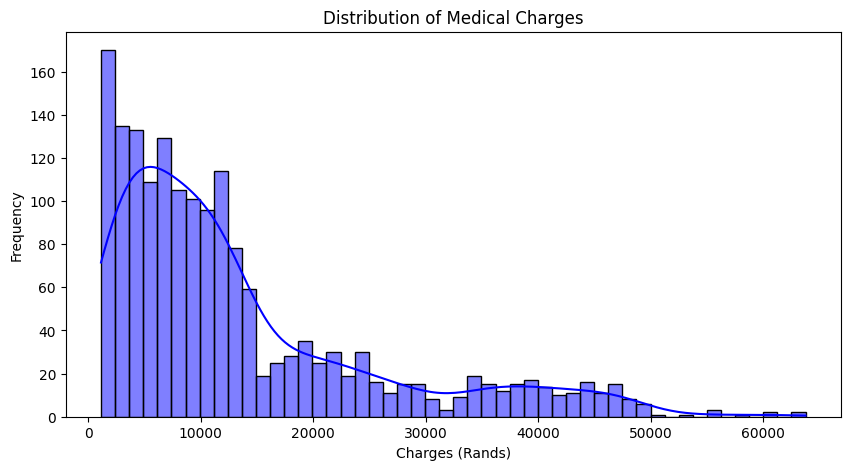

/tmp/ipykernel_575/1971254840.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df, palette='Set2')


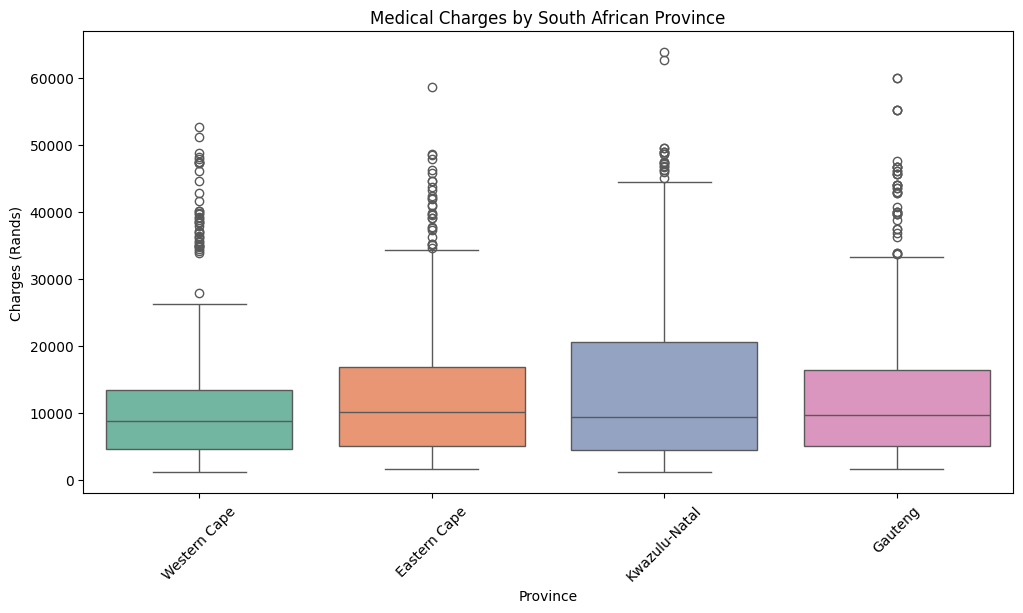

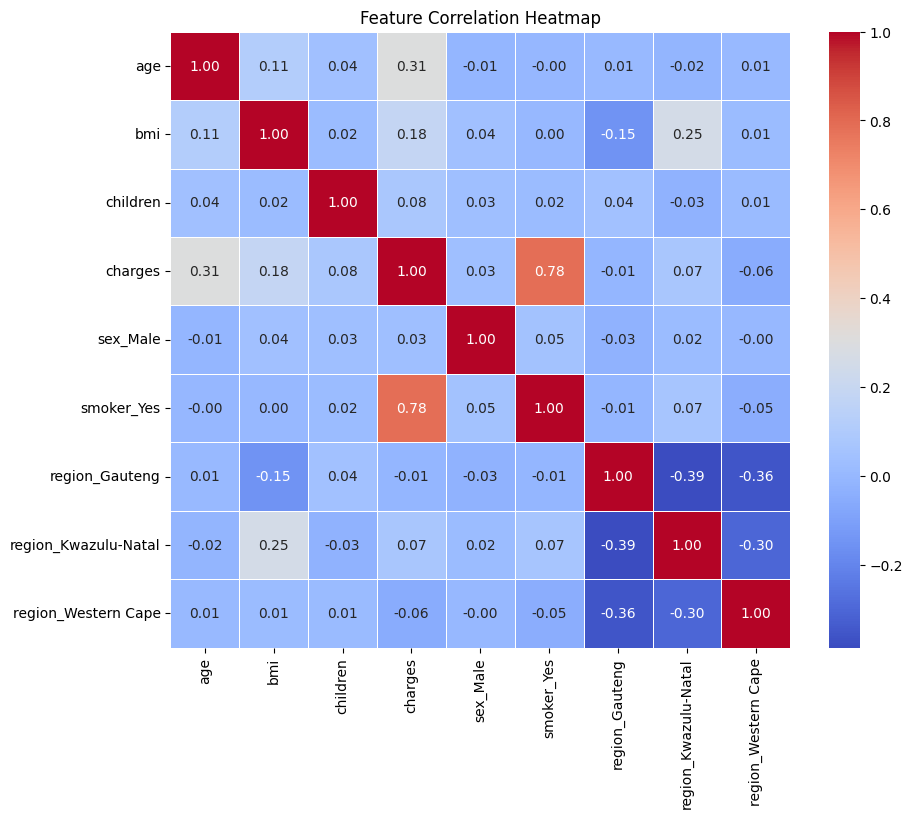

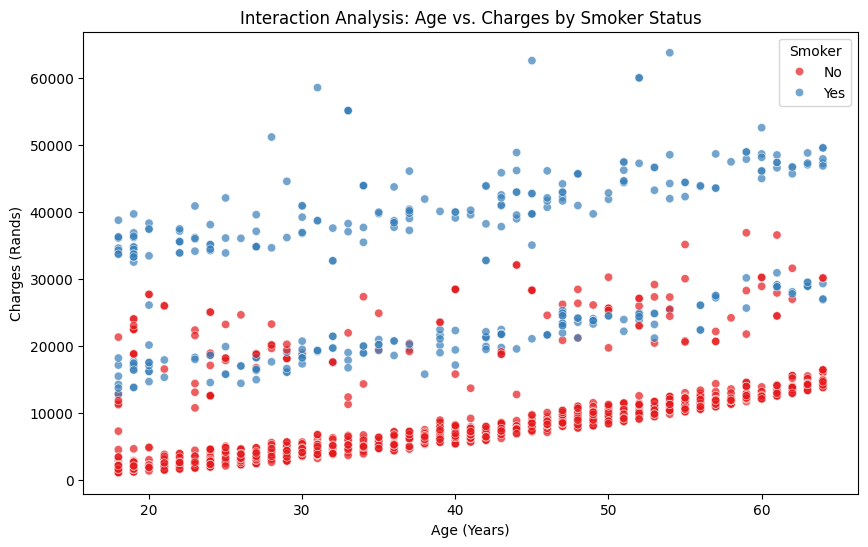

In [98]:
# 1. Distribution of Medical Spend (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='blue', bins=50)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges (Rands)")
plt.ylabel("Frequency")
plt.show()
# Logic Insight: Observe if the tail pulls to the right (Right-Skewed) or looks like a bell curve (Normal).

# 2. Medical Expenditure by Province (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=df, palette='Set2')
plt.title("Medical Charges by South African Province")
plt.xlabel("Province")
plt.ylabel("Charges (Rands)")
plt.xticks(rotation=45)
plt.show()
# Logic Insight: Look for the boxplot with the highest horizontal line inside the box (the median).

# 3. Correlation Analysis (Heatmap)
# We must encode categorical variables into numbers before calculating correlation
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10, 8))
# Calculate the correlation matrix and plot it
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
# Logic Insight: Find the row/column for 'charges'. Look for the highest positive number (closest to 1.0) ignoring 'charges' itself.

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Interaction Analysis: Age vs. Charges by Smoker Status')
plt.xlabel('Age (Years)')
plt.ylabel('Charges (Rands)')
plt.legend(title='Smoker')